In [2]:
from pathlib import Path
import numpy as np
import scipy.stats as stats
import xarray as xr
import matplotlib.pyplot as plt

In [20]:
def test_significance(
    bin_stats: xr.DataArray,
    alpha: float = 0.05,
    n_min: int = 10,
) -> xr.DataArray:
    """
    Test binned means against H0: μ = 0.
    For signficance, the sample size must also be greater than `n_min`
    """
    means = bin_stats.sel(stats='mean')
    stds = np.sqrt(bin_stats.sel(stats='var_samp'))
    ns = bin_stats.sel(stats='count')

    # Calculate t-statistic and critical value
    t_critical = stats.t.ppf(1 - alpha / 2, ns - 1)
    t_statistic = means / (stds / np.sqrt(ns))

    # Perform significance test
    return (np.abs(t_statistic) > t_critical) & (bin_stats.sel(stats='count') > n_min)

In [69]:
ROOT = Path("/glade/work/bbuchovecky/et_unc/proc/cmip6/cmip6/qbin")
pattern = "cmip6.*.evspsbl.qbin.199501-201412.*.nc"

bs = {}
bs_list = []
source_id = []
for f in sorted(ROOT.glob("cmip6.*.evspsbl.qbin_pooled.199501-201412.*.nc")):
    keys = f.stem.split(".")
    sid = keys[1]
    print(f"{sid:15}: {f.name}")
    bs[sid] = xr.open_mfdataset(f)

    bs_list.append(bs[sid]["evspsbl"])
    source_id.append(sid)

bs_pool = xr.concat(bs_list, dim="source_id").assign_coords(source_id=source_id)
bs_frac_cnt = bs_pool.sel(stats="count") / bs_pool.sel(stats="count").sum(dim=["x_bin", "y_bin"]) * 100
bs_frac_sid = (bs_frac_cnt>0).sum(dim="source_id") / len(bs_frac_cnt.source_id)

ACCESS-ESM1-5  : cmip6.ACCESS-ESM1-5.evspsbl.qbin_pooled.199501-201412.r1i1p1f1.nc
AWI-ESM-1-1-LR : cmip6.AWI-ESM-1-1-LR.evspsbl.qbin_pooled.199501-201412.r1i1p1f1.nc
CESM2-FV2      : cmip6.CESM2-FV2.evspsbl.qbin_pooled.199501-201412.r1i1p1f1.nc
CESM2-WACCM    : cmip6.CESM2-WACCM.evspsbl.qbin_pooled.199501-201412.r1i1p1f1.nc
CESM2          : cmip6.CESM2.evspsbl.qbin_pooled.199501-201412.r1i1p1f1.nc
CMCC-CM2-SR5   : cmip6.CMCC-CM2-SR5.evspsbl.qbin_pooled.199501-201412.r1i1p1f1.nc
CMCC-ESM2      : cmip6.CMCC-ESM2.evspsbl.qbin_pooled.199501-201412.r1i1p1f1.nc
CNRM-CM6-1     : cmip6.CNRM-CM6-1.evspsbl.qbin_pooled.199501-201412.r2i1p1f2.nc
CNRM-ESM2-1    : cmip6.CNRM-ESM2-1.evspsbl.qbin_pooled.199501-201412.r2i1p1f2.nc
CanESM5-CanOE  : cmip6.CanESM5-CanOE.evspsbl.qbin_pooled.199501-201412.r1i1p2f1.nc
CanESM5        : cmip6.CanESM5.evspsbl.qbin_pooled.199501-201412.onemember.nc
E3SM-1-0       : cmip6.E3SM-1-0.evspsbl.qbin_pooled.199501-201412.onemember.nc
E3SM-1-1-ECA   : cmip6.E3SM-1-1-ECA.

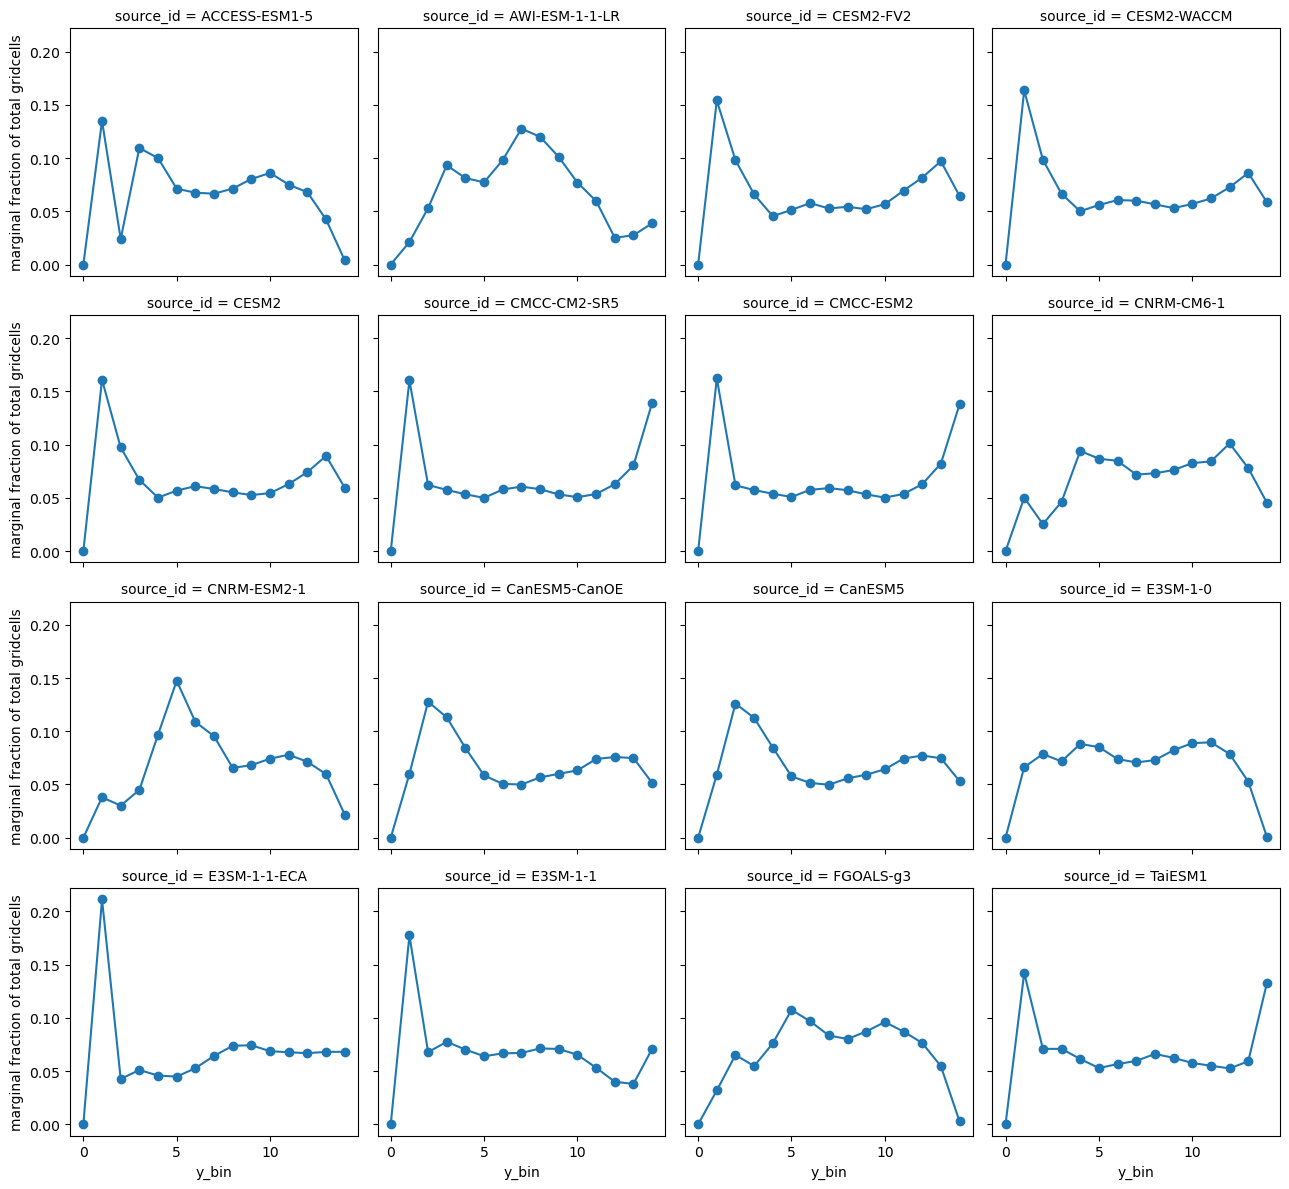

In [38]:
fg = (bs_pool.sel(stats="count").sum(dim="x_bin") / bs_pool.sel(stats="count").sum(dim=["x_bin", "y_bin"])).plot(col="source_id", col_wrap=4, marker="o")
fg.set_xlabels("y_bin")
fg.set_ylabels("marginal fraction of total gridcells")

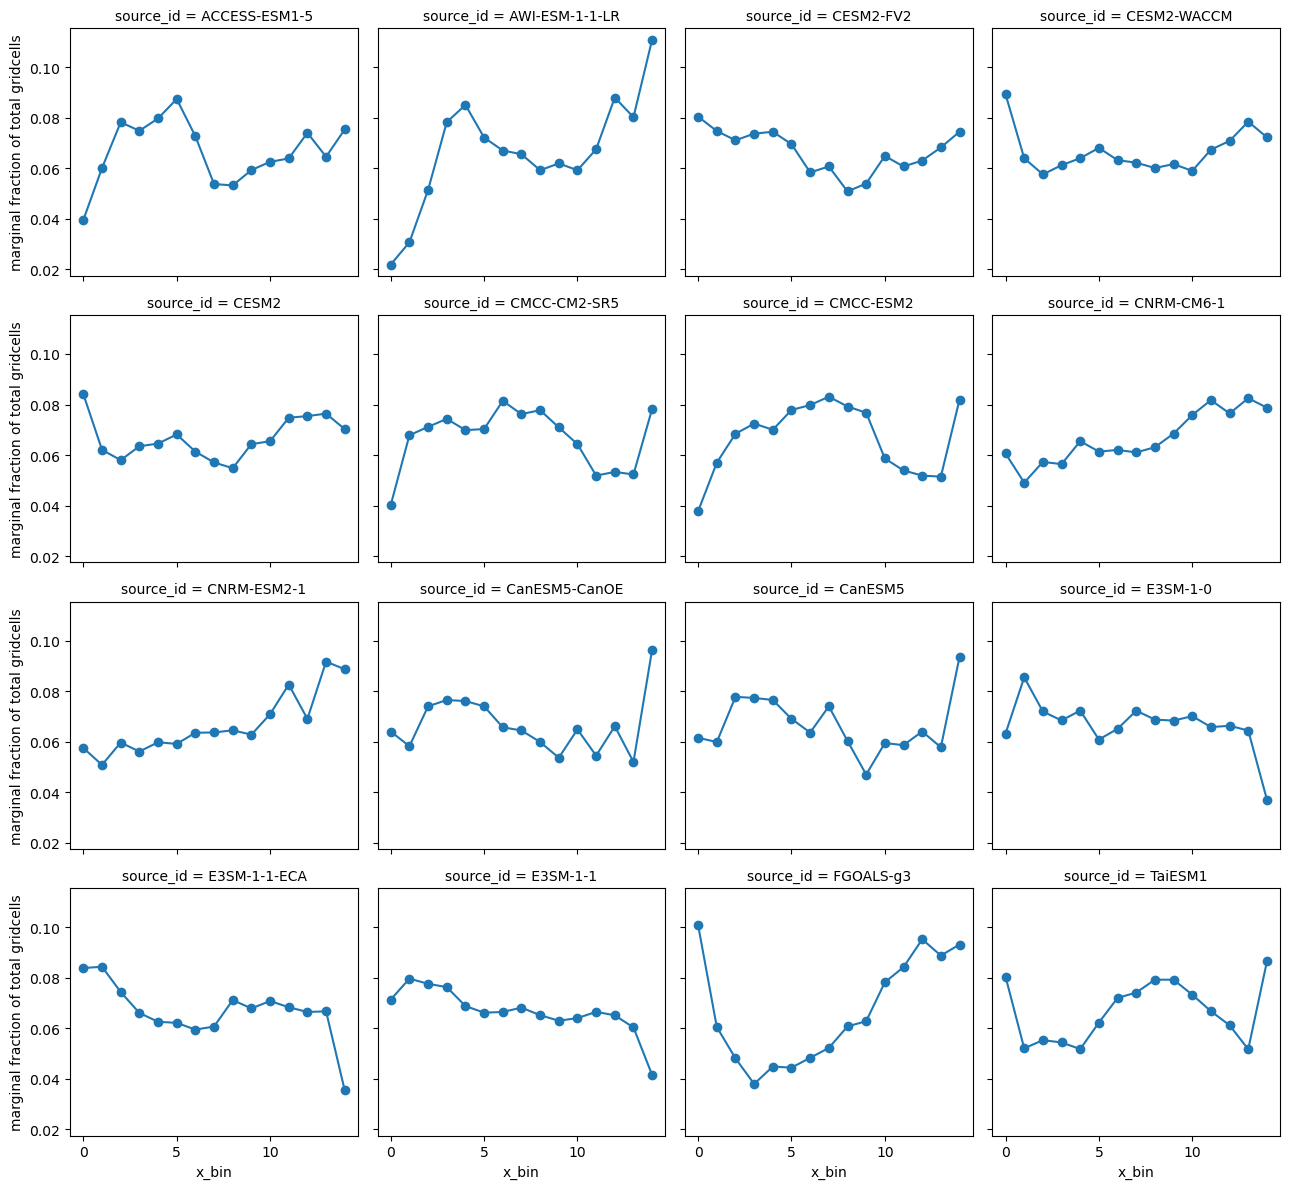

In [37]:
fg = (bs_pool.sel(stats="count").sum(dim="y_bin") / bs_pool.sel(stats="count").sum(dim=["x_bin", "y_bin"])).plot(col="source_id", col_wrap=4, marker="o")
fg.set_xlabels("x_bin")
fg.set_ylabels("marginal fraction of total gridcells")

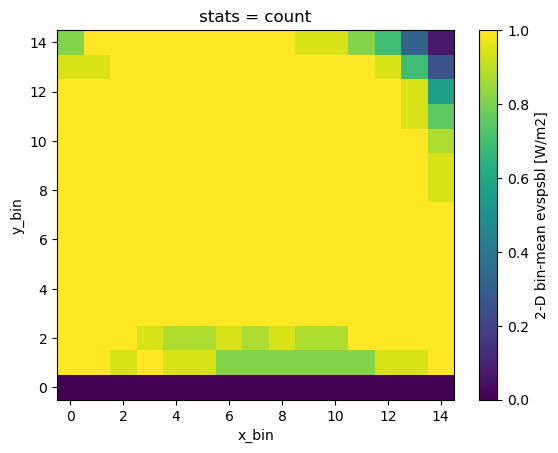

In [57]:
bs_frac_sid.plot()

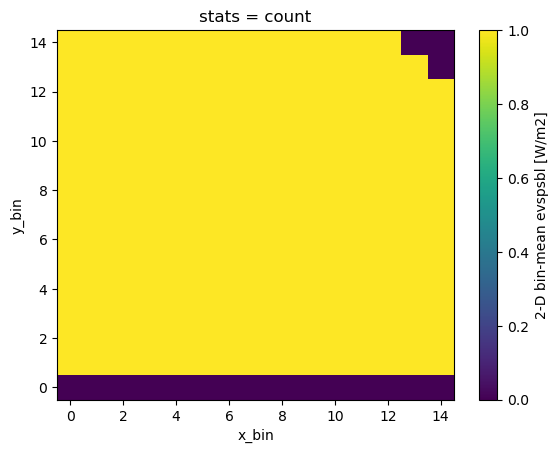

In [61]:
(bs_frac_sid>0.5).plot()

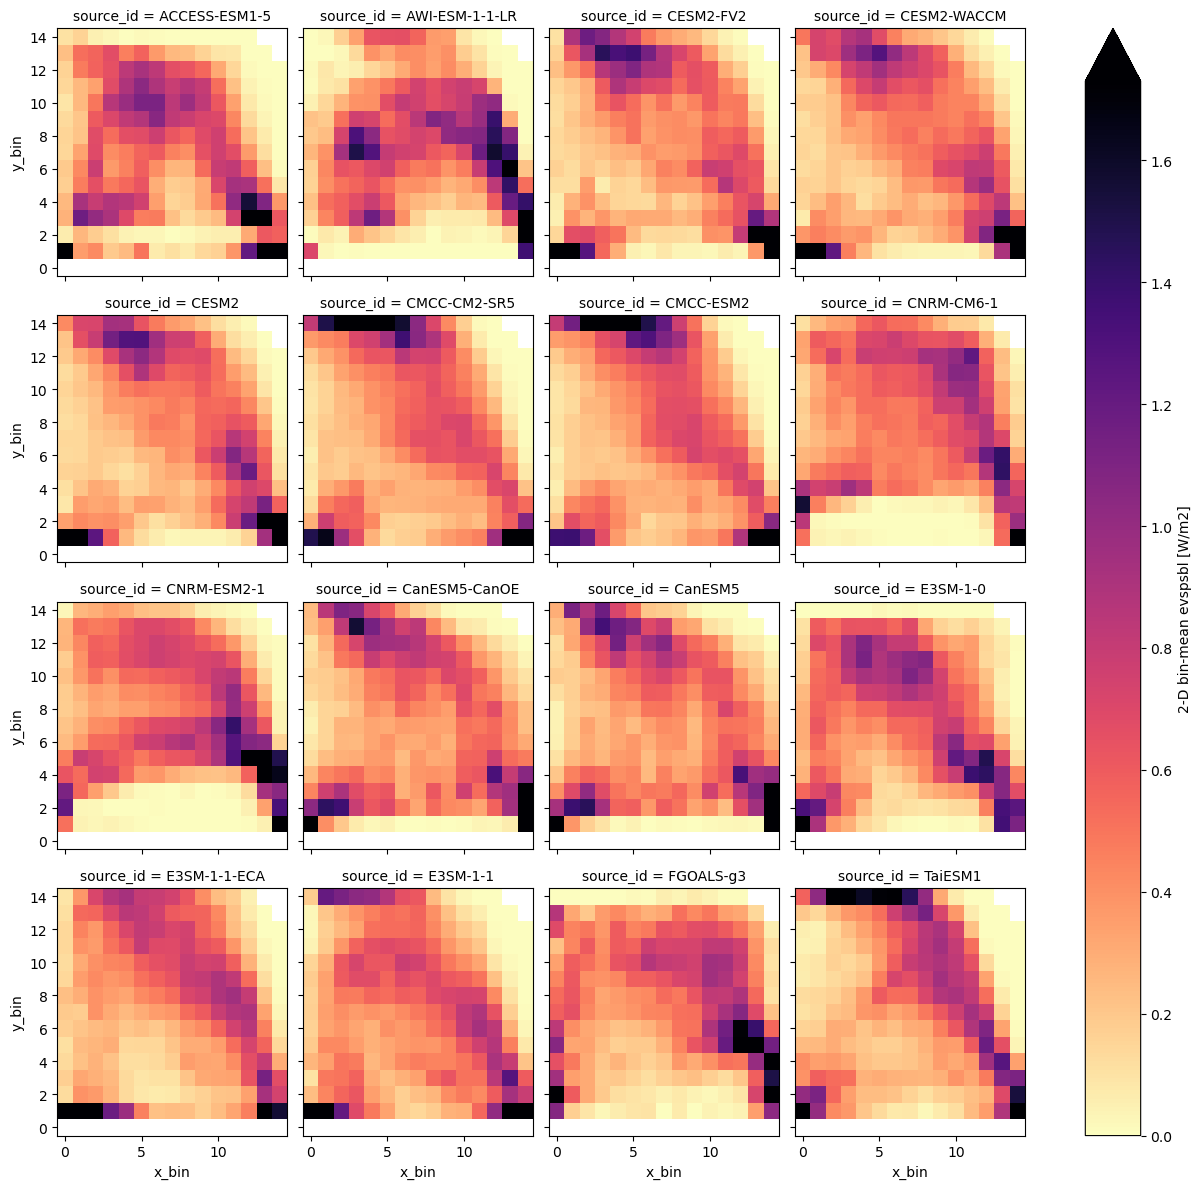

In [ ]:
bs_frac_cnt.where(bs_frac_sid>0.5).plot(col="source_id", col_wrap=4, cmap="magma_r", vmin=0, robust=True)

/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


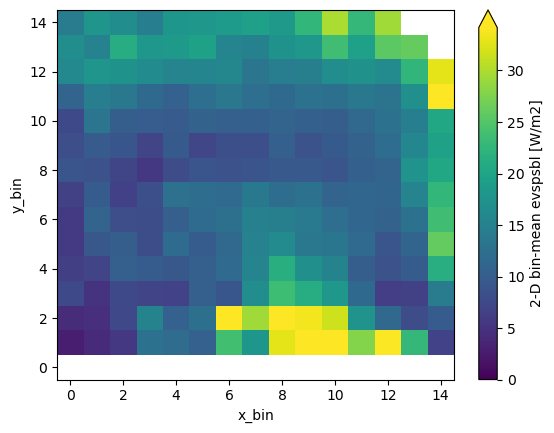

In [68]:
bs_pool.sel(stats="mean").where(bs_frac_sid>0.5).std(dim="source_id").plot(robust=True, vmin=0)

In [5]:
ai_bins = xr.open_dataset("/glade/work/bbuchovecky/et_unc/proc/qbin_edges/cmip6.ai_clim.15_quantiles_pooled.199501-201412.nc")["ai"]
lai_bins = xr.open_dataset("/glade/work/bbuchovecky/et_unc/proc/qbin_edges/cmip6.lai_mon.15_quantiles_pooled.199501-201412.nc")["lai"]

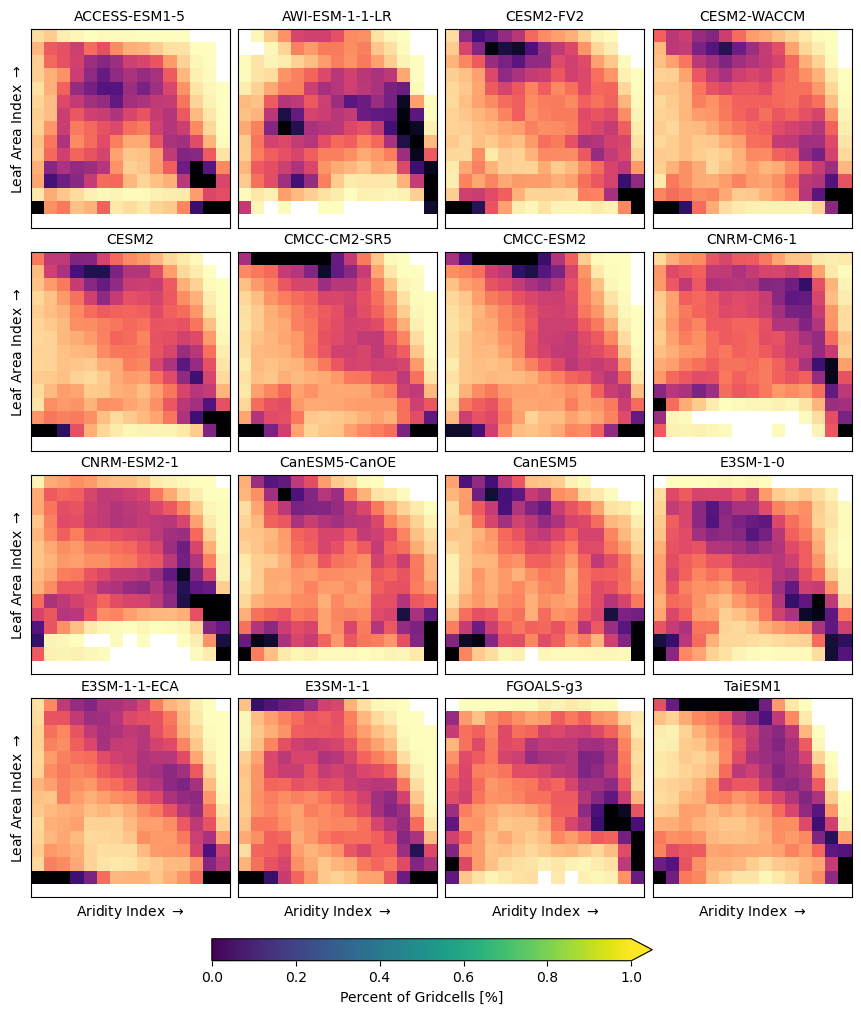

In [73]:
subplot_kwargs = dict(
    vmin=0,
    vmax=1.5,
    cmap="magma_r",
    add_colorbar=False,
    add_labels=False,
)

fig, axes = plt.subplots(4, 4, figsize=(8.5, 10), sharex=True, sharey=True, subplot_kw=dict(box_aspect=1), layout="constrained")
axs = axes.ravel()

im = None
for i, sid in enumerate(bs_frac_cnt.source_id):
    bs_frac_cnt.where(bs_frac_cnt>0).sel(source_id=sid).plot(ax=axs[i], **subplot_kwargs)
    axs[i].set_title(sid.item(), fontsize=10)
    axs[i].set_xticks([])
    axs[i].set_yticks([])

for i in range(4):
    axes[-1, i].set_xlabel("Aridity Index $\\rightarrow$")
    axes[i, 0].set_ylabel("Leaf Area Index $\\rightarrow$")

cb = fig.colorbar(im, ax=axs, extend="max", orientation="horizontal", fraction=0.025, pad=0.02)
cb.set_label("Percent of Gridcells [%]")

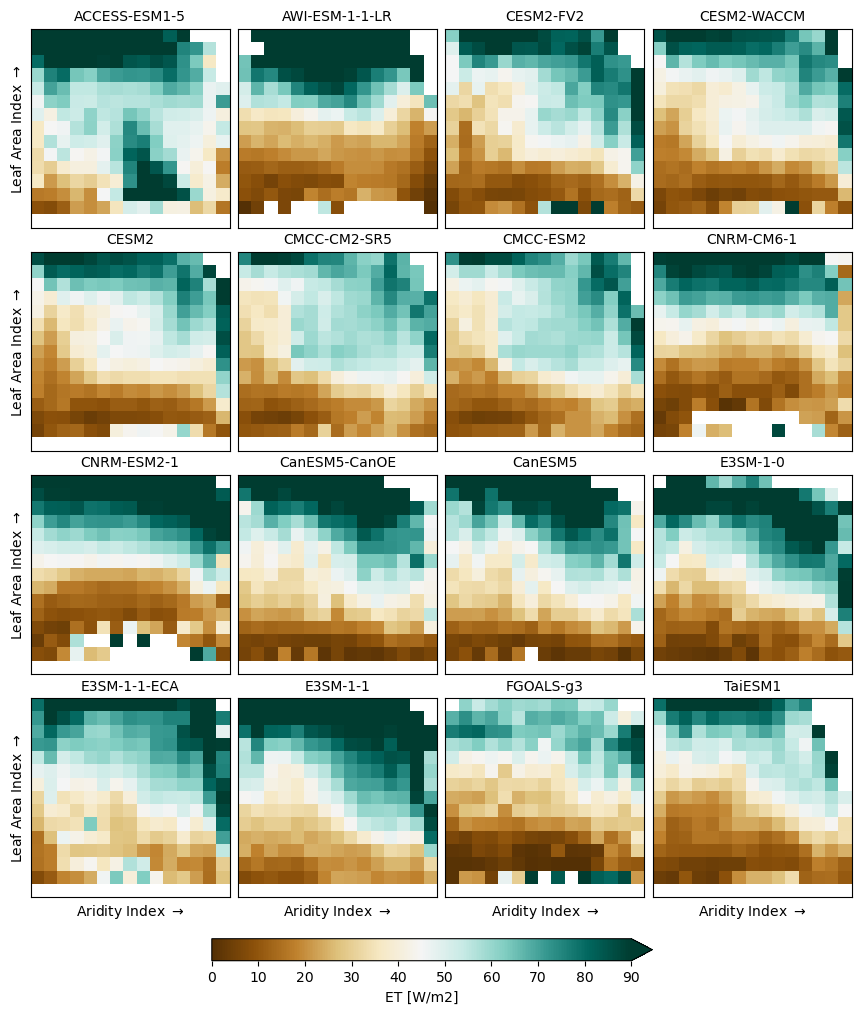

In [78]:
subplot_kwargs = dict(
    vmin=0,
    vmax=90,
    cmap="BrBG",
    add_colorbar=False,
    add_labels=False,
)

fig, axes = plt.subplots(4, 4, figsize=(8.5, 10), sharex=True, sharey=True, subplot_kw=dict(box_aspect=1), layout="constrained")
axs = axes.ravel()

im = None
for i, sid in enumerate(bs_pool.source_id):
    im = bs_pool.where(bs_frac_cnt>0).sel(source_id=sid, stats="mean").plot(ax=axs[i], **subplot_kwargs)
    axs[i].set_title(sid.item(), fontsize=10)
    axs[i].set_xticks([])
    axs[i].set_yticks([])

for i in range(4):
    axes[-1, i].set_xlabel("Aridity Index $\\rightarrow$")
    axes[i, 0].set_ylabel("Leaf Area Index $\\rightarrow$")

cb = fig.colorbar(im, ax=axs, extend="max", orientation="horizontal", fraction=0.025, pad=0.02)
cb.set_label("ET [W/m2]")